# Information Theory Based Parameter Correlation

This notebook is used as a research internship project that applies information theory to machine learning parameter correlation analysis.

*Author: Lawrence Zhang, University of Glasgow*

*Supervisor: Ankush Aggarwal, University of Glasgow*

## Imports




#### Dependencies

Calculation: numpy, fraction, NPEET (entropy estimator tool, contained in the repo), sklearn PCA (technically this can be done with only numpy but here scikit-learn is used for convenience)

Data visualisation: matplotlib

In [76]:
#set-ups
import numpy as np
import matplotlib.pyplot as plt
from npeet import entropy_estimators as ee
from sklearn.decomposition import PCA
from fractions import Fraction

In [77]:
#test use

x = np.array([[1.3], [3.7], [5.1], [2.4], [3.4]])
y = np.array([[1.5], [3.32], [5.3], [2.3], [3.3]])

print(ee.mi(x,y))

X = np.column_stack([x, y])
pca = PCA()
pca.fit(X)

print(pca.components_)
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)
print("ready to run")

0.16831442143704642
[[ 0.70775233  0.70646065]
 [-0.70646065  0.70775233]]
[4.03694334 0.02973666]
[0.99268773 0.00731227]
ready to run


### Background Notes

#### PCA: Principle Component Analysis

Analysis tool used to determine principle component, in other words identify the directions along which the data varies the most.

PC1 is defined as the direction of max variance which contains most information. PC2 is orthogonal to PC1, capturing remaining variance.

##### Theoretical

Given a centered data matrix

$$
X \in \mathbb{R}^{n \times p}
$$

the covariance matrix is

$$
C = \frac{1}{n-1}X^TX
$$

PCA computes the eigenvalue decomposition (very similar to SVD)

$$
C = V\Lambda V^T
$$

where:

- $V$: eigenvectors (principal directions)
- $\Lambda$: eigenvalues (variance explained by each direction)

The principal components are ordered according to decreasing eigenvalues.

##### Application Use

*For use, refer to https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html for more details*


#### EE: Entropy Estimator

##### Theoretical

###### MI

Given two random variables \(X\) and \(Y\), with joint distribution

$$
p(x,y)
$$

and marginal distributions

$$
p(x), \quad p(y),
$$

the mutual information is defined as

$$
I(X;Y)
=
\int\int
p(x,y)
\log
\frac{p(x,y)}
     {p(x)p(y)}
\,dx\,dy
$$

Equivalent entropy-based formulations are

$$
I(X;Y)
=
H(X)-H(X|Y)
$$

$$
I(X;Y)
=
H(Y)-H(Y|X)
$$

$$
I(X;Y)
=
H(X)+H(Y)-H(X,Y)
$$

where:

- \(H(X)\): entropy of \(X\)
- \(H(Y)\): entropy of \(Y\)
- \(H(X,Y)\): joint entropy
- \(H(X|Y)\): conditional entropy

Interpretation:

- \(I(X;Y)=0\): \(X\) and \(Y\) are independent
- Larger \(I(X;Y)\): stronger dependence
- Captures both linear and nonlinear relationships

###### CMI

Given three random variables \(X\), \(Y\), and \(Z\), the conditional mutual information is defined as

$$
I(X;Y|Z)
=
\iiint
p(x,y,z)
\log
\frac{p(x,y|z)}
     {p(x|z)p(y|z)}
\,dx\,dy\,dz
$$

Equivalent entropy formulation:

$$
I(X;Y|Z)
=
H(X|Z)-H(X|Y,Z)
$$

or

$$
I(X;Y|Z)
=
H(X,Z)+H(Y,Z)-H(Z)-H(X,Y,Z)
$$

where:

- \(H(X|Z)\): conditional entropy of \(X\) given \(Z\)
- \(H(X|Y,Z)\): remaining uncertainty in \(X\) after observing \(Y\) and \(Z\)

Interpretation:

- \(I(X;Y|Z)=0\): \(X\) and \(Y\) are conditionally independent given \(Z\)
- Large values indicate dependence remains even after conditioning on \(Z\)


##### Application Use

*The NPEET library uses a KNN algorithm for calculation, so the result might be < 0*

*For use, refer to https://github.com/gregversteeg/NPEET for more details*

## Linear Combination (without noise)

In this section, some linear combinations of parameters will be tested through both entropy test and PCA, and comparing their results. 

It is suggested to check with manually constructed relationships first. Some helper functions are defined as below:


In [37]:
#helper functions
def show_2d(x,y): #visualisation
    plt.figure(figsize=(3, 3))
    plt.scatter(x, y)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.axis('equal') 
    plt.show()
    
def show_3d(a,b,y): #visualisation
    fig = plt.figure(figsize=(6,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(a, b, y, s=5)
    ax.set_xlabel('a')
    ax.set_ylabel('b')
    ax.set_zlabel('y')
    ax.view_init(elev=30, azim=45)

    plt.show()
    
def pca_2d(a,b,y): #data
    print("PCA:")
    pca.fit(np.column_stack([y, a]))
    print(pca.components_)
    print("Variance ratio (y,a): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([y, b]))
    print(pca.components_)
    print("Variance ratio (y,b): " + str(pca.explained_variance_ratio_))
    pca.fit(np.column_stack([a, b, y]))
    print(pca.components_)
    print("Variance ratio (a,b,y): " + str(pca.explained_variance_ratio_))
    print("--------------------------")
    
def ee_2d(a,b,y): #data
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("--------------------------")
    

### 2D experiment

Run corresponding cells (or create new cells) to get different parameter pairs and combinations:

In [79]:
#run this first and get randomly generated a & b
a = np.random.randn(1000)
b = np.random.randn(1000)

In [80]:
y = a

In [28]:
y = a + b

In [127]:
y = 2*a + 0.5*b

In [84]:
y = 3*a + 0.0001*b

EE:
I(y;a): 7.352249539661056
I(y;b): 0.00404581877109083
I(a;y|b): 3.6880200899546676
I(b;y|a): -0.1368081201994912
--------------------------
PCA:
[[ 0.89442719  0.4472136 ]
 [-0.4472136   0.89442719]]
Variance ratio (y,a): [1. 0.]
[[ 0.99931061 -0.03712562]
 [ 0.03712562  0.99931061]]
Variance ratio (y,b): [0.81226698 0.18773302]
[[ 4.46994075e-01 -3.13286618e-02  8.93988150e-01]
 [ 1.40106035e-02  9.99509137e-01  2.80212069e-02]
 [ 8.94427191e-01 -1.66533454e-16 -4.47213595e-01]]
Variance ratio (a,b,y): [8.43886095e-01 1.56113905e-01 1.83868892e-18]
--------------------------


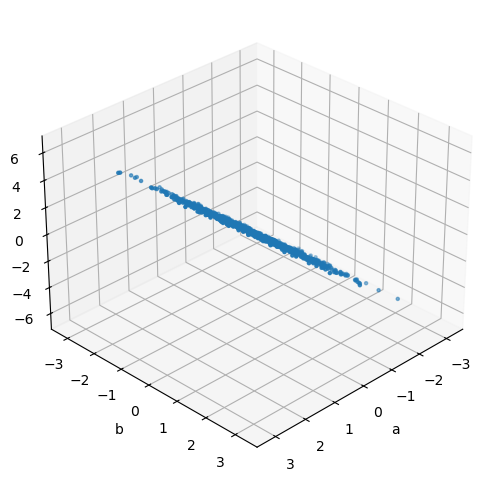

In [146]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation

__Please make sure you run the *results* cell to update PCA results__

PCA extracts orthogonal directions that explain the variance structure of the data. The first term in pca_components is the direction that maximises the variance (change). If the associated variance is close to zero, it may indicate an approximate linear constraint among the variables.

The interpretation approach is to check the explained variance ratio of the last principal component. When the value is negligible (the threshold is set to be 1e-8), it suggests that the corresponding eigenvector may represent an approximate linear relationship among the variables.. Fraction module is used to approximate the ratio. Note that although the interpreter works well on manually constructed relationships, it is not tested against actual experiment data.

The interpreter function below takes 3 parameters, pca_components, pca_ratio and param_names. The last argument is optional.

The exact format of the restored relationship (which term sits on LHS) depends on the argument order passed to pca calculation function.

In [115]:
def pca_interpretation(components, ratio, param_names=None):
    if len(ratio) != len(components):
        print("Invalid inputs")
        return
    if ratio[-1] >= 1e-6: #when the last component ratio is negletable, it means this direction fits orginal correlation well
        print("No significant linear relationship is found in this PCA analysis.")
        return
    v = np.array(components[-1])
    v = v / np.min(np.abs(v[np.abs(v) > 1e-8])) #threshold
    coeffs = [Fraction(x).limit_denominator(10) for x in v]
    
    print("Detected ratio:")
    print(coeffs)
    
    if param_names is None:
        param_names = [chr(ord('a') + i) for i in range(len(coeffs))] #ascii
        
    lhs_coeff = -coeffs[-1]
    lhs_var = param_names[-1]

    rhs_terms = []

    for c, name in zip(coeffs[:-1], param_names[:-1]):

        if c == 0:
            continue

        sign = "+" if c > 0 else "-"

        rhs_terms.append(
            (sign, abs(c), name)
        )

    equation = f"{lhs_coeff}{lhs_var} = "

    first = True

    for sign, c, name in rhs_terms:

        if first:
            if sign == "-":
                equation += "-"
            equation += f"{c}{name}"
            first = False
        else:
            equation += f" {sign} {c}{name}"

    print("\nApproximate relation:")
    print(equation)

In [129]:
#example use
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(4, 1), Fraction(1, 1), Fraction(-2, 1)]

Approximate relation:
2c = 4a + 1b


### 3D & Higher Dimensions

Add new cells to get more combinations.

In [121]:
#helper functions
def ee_3d(a,b,c,y):
    print("EE:")
    print("I(y;a): " + str(ee.mi(y,a)))
    print("I(y;b): " + str(ee.mi(y,b)))
    print("I(y;c): " + str(ee.mi(y,b)))
    print("I(a;y|b): " + str(ee.cmi(a,y,b)))
    print("I(b;y|a): " + str(ee.cmi(b,y,a)))
    print("I(c;y|b): " + str(ee.cmi(c,y,b)))
    print("I(c;y|a): " + str(ee.cmi(c,y,a)))
    print("I(a;y|c): " + str(ee.cmi(a,y,c)))
    print("I(b;y|c): " + str(ee.cmi(b,y,c)))
    print("--------------------------")
    
def pca_3d(a,b,c,y): #pca result becomes hard to interpret so normalisation is used here
    print("PCA:")
    pca.fit(np.column_stack([a, b, c, y]))
    print(pca.components_)
    print("Variance ratio: " + str(pca.explained_variance_ratio_))
    print("--------------------------")

In [122]:
c = np.random.randn(1000)

y = a + 13*b - 4*c

In [123]:
y = -3*b + 2*c

In [145]:
#results 3D
ee_3d(a,b,c,y)
pca_3d(a,b,c,y)

EE:
I(y;a): 7.352249539661056
I(y;b): 0.00404581877109083
I(y;c): 0.00404581877109083
I(a;y|b): 3.6880200899546676
I(b;y|a): -0.1368081201994912


AssertionError: Arrays should have same length

In [130]:
#interpretation
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(4, 1), Fraction(1, 1), Fraction(-2, 1)]

Approximate relation:
2c = 4a + 1b


In [139]:
#helper functions to get randomly generated linear combinations
def generate_linear_problem(
        n,
        sample_size=1000,
        coeff_range=(-20,20),
        seed=None):
    if seed is not None:
        np.random.seed(seed)

    X = np.random.randn(sample_size, n)
    coeffs = np.random.randint(
        coeff_range[0],
        coeff_range[1] + 1,
        size=n
    )
    while np.all(coeffs == 0):
        coeffs = np.random.randint(
            coeff_range[0],
            coeff_range[1] + 1,
            size=n
        )
    y = X @ coeffs
    return X, y, coeffs

def pca_nd(X, y):
    data = np.column_stack([X, y])
    pca.fit(data)
    print("PCA:")
    print(pca.components_)
    print("Variance ratio:")
    print(pca.explained_variance_ratio_)

def ee_nd(X, y):
    n = X.shape[1]
    print("EE:")

    for i in range(n):
        print(
            f"I(y;x{i+1}): "
            + str(ee.mi(y, X[:, i]))
        )

    for target in range(n):

        others = [j for j in range(n) if j != target]

        for cond in others:

            print(
                f"I(x{target+1};y|x{cond+1}): "
                + str(
                    ee.cmi(
                        X[:, target],
                        y,
                        X[:, cond]
                    )
                )
            )
    print("--------------------------")

In [140]:
X,y,c = generate_linear_problem(5) #an example randomly-generated linear combination
print(c) #coefficients
pca_nd(X,y)
ee_nd(X,y)

[ 11  13  12  17 -18]
PCA:
[[ 1.08666493e-02  1.24948585e-02  1.11207870e-02  1.72108274e-02
  -1.61956599e-02  9.99521691e-01]
 [-2.05495240e-01  6.95350679e-01 -6.84708225e-01  6.82901436e-03
  -7.33970662e-02 -1.47086607e-04]
 [ 8.85243918e-02 -2.80827831e-01 -3.44688443e-01  8.05284809e-01
   3.82104366e-01 -1.29165602e-03]
 [-2.64900179e-01  4.92013166e-01  5.11411903e-01  1.14641390e-01
   6.42702019e-01 -5.20699302e-04]
 [ 8.74177862e-01  1.84744538e-01 -1.15300204e-01 -2.49534610e-01
   3.55134669e-01 -4.79403963e-04]
 [-3.39791135e-01 -4.01571341e-01 -3.70681238e-01 -5.25131754e-01
   5.56021857e-01  3.08901032e-02]]
Variance ratio:
[9.96630356e-01 9.14932143e-04 8.58557563e-04 8.12203250e-04
 7.83950635e-04 0.00000000e+00]
EE:
I(y;x1): 0.12801459638366253
I(y;x2): 0.1800874273538311
I(y;x3): 0.034861042390392484
I(y;x4): 0.255376312820129
I(y;x5): 0.22707112319117398
I(x1;y|x2): 0.108343351844905
I(x1;y|x3): 0.10672978975574826
I(x1;y|x4): 0.11140880836120748
I(x1;y|x5): 0.13

In [141]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(-11, 1), Fraction(-13, 1), Fraction(-12, 1), Fraction(-17, 1), Fraction(18, 1), Fraction(1, 1)]

Approximate relation:
-1f = -11a - 13b - 12c - 17d + 18e


## Non-Linear Combination (Manually generated)

Some non-linear combinations will be tested.



In [118]:
y = a**2

EE:
I(y;a): 6.213030277714402
I(y;b): 0.03927019222261746
I(a;y|b): 2.5562202850619338
I(b;y|a): -0.10265146948081261
--------------------------
PCA:
[[ 0.99995374  0.00961856]
 [-0.00961856  0.99995374]]
Variance ratio (y,a): [0.66111402 0.33888598]
[[ 0.9996888  -0.02494593]
 [ 0.02494593  0.9996888 ]]
Variance ratio (y,b): [0.67743716 0.32256284]
[[ 0.0111432  -0.02556404  0.99961108]
 [ 0.87416759 -0.4851189  -0.02215124]
 [ 0.4854965   0.87407444  0.01694148]]
Variance ratio (a,b,y): [0.50288375 0.26582028 0.23129597]
--------------------------


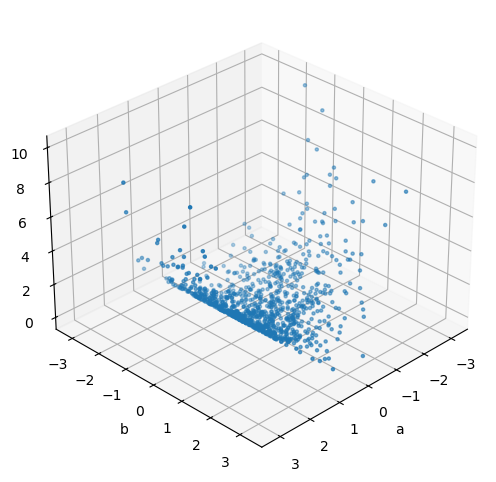

In [119]:
#results
ee_2d(a,b,y)
pca_2d(a,b,y)
show_3d(a,b,y)

#### Interpretation

PCA could only recognise linear combinations, therefore, pca_interpretation does not work as linear examples above (no negligible value in explained_variance_ratio).

However, EE would still work and recognises there's a pattern between y and a.

In [142]:
pca_interpretation(pca.components_, pca.explained_variance_ratio_)

Detected ratio:
[Fraction(-11, 1), Fraction(-13, 1), Fraction(-12, 1), Fraction(-17, 1), Fraction(18, 1), Fraction(1, 1)]

Approximate relation:
-1f = -11a - 13b - 12c - 17d + 18e


## Linear Combination (with noise)

As shown above, pure linear combinations can be easily recognised by PCA method, with a very high accuracy.

In this section some noise will be introduced to data and see the comparison between two methods.

Noise_level is defined in the cell below, and modifications could be made to change the noise level. Note that noise level here is __not percentage__.

In [166]:
#noise set-up
noise_level = [0, 0.002, 0.05, 0.1, 0.2, 0.5, 1] #values

def add_noise(y):
    ys = []

    for sigma in noise_level:
        noise = np.random.normal(
            0,
            sigma,
            len(y)
        )
        ys.append(y + noise)

    return ys

In [167]:
y = 2*a

In [169]:
#results
ys = add_noise(y)

for sigma, y_noisy in zip(noise_level, ys):
    print(f"Noise level = {sigma}")
    ee_2d(a, b, y_noisy)
    pca_2d(a, b, y_noisy)
    pca_interpretation(pca.components_, pca.explained_variance_ratio_)
    print("===========================")

Noise level = 0
EE:
I(y;a): 7.352249539661056
I(y;b): 0.00404581877109083
I(a;y|b): 3.6880200899546676
I(b;y|a): -0.1368081201994912
--------------------------
PCA:
[[ 0.89442719  0.4472136 ]
 [-0.4472136   0.89442719]]
Variance ratio (y,a): [1. 0.]
[[ 0.99931061 -0.03712562]
 [ 0.03712562  0.99931061]]
Variance ratio (y,b): [0.81226698 0.18773302]
[[ 4.46994075e-01 -3.13286618e-02  8.93988150e-01]
 [ 1.40106035e-02  9.99509137e-01  2.80212069e-02]
 [ 8.94427191e-01 -1.66533454e-16 -4.47213595e-01]]
Variance ratio (a,b,y): [8.43886095e-01 1.56113905e-01 1.83868892e-18]
--------------------------
Detected ratio:
[Fraction(2, 1), Fraction(0, 1), Fraction(-1, 1)]

Approximate relation:
1c = 2a
Noise level = 0.002
EE:
I(y;a): 7.357476056057078
I(y;b): 0.0016479708325517336
I(a;y|b): 3.6867462845352343
I(b;y|a): -0.1396407297750774
--------------------------
PCA:
[[ 0.89442709  0.4472138 ]
 [-0.4472138   0.89442709]]
Variance ratio (y,a): [9.99999842e-01 1.57837161e-07]
[[ 0.9993111  -0.037

#### Interpretation

As noise level increases, PCA's ability to recognise linear combinations decreases very fast. It could barely handle data with noises.

In contrast, entropy estimator still recognises patterns

In [ ]:
#MI & CMI only provides information about what parameters are correlated
#use optimisation for ee result?
#try combinations and estimate the coefficients?
#try with 2d results first, not sure how the objective function should be written with more dimensions